In [4]:
from astroquery.vizier import Vizier
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from astropy.coordinates import SkyCoord, Angle
from astropy import units as u
from scipy.stats import norm
from scipy.optimize import curve_fit
import synthpop as sp
from mulens_rates import misc_utils
import pdb

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
v = Vizier(catalog="II/387/virac2")
v.ROW_LIMIT = -1

In [18]:
l=-10;b=-10
tcat = pd.read_hdf(f'outputfiles/virac/virac_l{l:.3f}_b{b:.3f}.h5')

In [20]:
tcat.columns

Index(['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist',
       'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR',
       'A_Ks', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius',
       'phase', 'VISTA_Z', 'VISTA_Y', 'VISTA_J', 'VISTA_H', 'VISTA_Ks'],
      dtype='object')

In [21]:
mod = sp.SynthPop(default_config='huston2025_defaults.synthpop_conf',
                          model_name="Huston2025", name_for_output='virac',
                          chosen_bands=["VISTA_Z", "VISTA_Y", "VISTA_J", "VISTA_H", "VISTA_Ks"],
                          maglim=['VISTA_Ks', 25, "remove"], output_location="outputfiles/virac",
                          skip_lowmass_stars=True, output_file_type='h5',
                          post_processing_kwargs={"name": "ProcessDarkCompactObjects","remove": False,
                                                  "name": "DropColumns", "column_names":['In_Final_Phase', 
                                                    'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR']},
                          opt_iso_props=[],
        )
mod.init_populations()



################################ Settings #################################
 2640524 - # reading default parameters from
 2640526 - default_config_file =  /Users/mhuston/code/synthpop/synthpop/config_files/huston2025_defaults.synthpop_conf 


# copy the following to a config file to redo this model generation -------
 2640527 - {
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "random_seed": 98142539,
    "name_for_output": "virac",
    "model_name": "Huston2025",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,
        "w_lsr": 0.53
    },
    "warp": {
        "r_warp": 7.72,
        "amp_warp": 0.06,
        "amp_warp_pos": null,
        "amp_warp_neg": null,
        "alpha_warp": 1

In [7]:
rad_deg = 0.05

In [8]:
def get_virac2(l,b):
    try:
        tab=pd.read_hdf(f'data/virac2/query_l{l:.3f}_b{b:.3f}.h5', key='data')
    except:
        print('Querying VIRAC2',l,b)
        coord = SkyCoord(l, b, unit=u.deg, frame='galactic')
        result = v.query_region(coord, radius=rad_deg*u.degree)[0]
        tab=result[result['UWE']<1.4]
        coords0 = SkyCoord(tab['RAJ2000'], tab['DEJ2000'],
                          pm_ra_cosdec=tab['pmRA'], pm_dec=tab['pmDE'], frame='icrs')
        coords = coords0.transform_to('galactic')
        tab['pml'] = coords.pm_l_cosb
        tab['pmb'] = coords.pm_b
        tab.to_pandas().to_hdf(f'data/virac2/query_l{l:.3f}_b{b:.3f}.h5', key='data')
        
    return tab

In [9]:
def generate_spcat(l,b):
    sptab = mod.process_location(l,b, solid_angle=np.pi*rad_deg**2)[0]

In [13]:
def get_spcat(l,b, blend=True):
    if blend:
        try:
            tab_bl=pd.read_hdf(f'outputfiles/virac/blended_l{l:.3f}_b{b:.3f}.h5')
            tab_bl['mul']
        except:
            try:
                sptab=pd.read_hdf(f'outputfiles/virac/virac_l{l:.3f}_b{b:.3f}.h5')
            except:
                sptab = mod.process_location(l,b, solid_angle=np.pi*rad_deg**2)[0]
            tab_bl = misc_utils.calc_blends(sptab[sptab['VISTA_Ks']<30], filters=['VISTA_J','VISTA_H','VISTA_Ks'], 
                                            blend_rad=0.36/3600, primary_filter='VISTA_Ks')
            tab_bl.to_hdf(f'outputfiles/virac/blended_l{l:.3f}_b{b:.3f}.h5', index=False)
        return tab_bl
    try:
        sptab=pd.read_hdf(f'outputfiles/virac/virac_l{l:.3f}_b{b:.3f}.h5')
    except:
        sptab = mod.process_location(l,b, solid_angle=np.pi*rad_deg**2)[0]
    return sptab

In [7]:
# col = 'pml'; spcol='mul'
# tabbins = np.linspace(-30,30,51)
# hist = plt.hist(tab[col], bins=tabbins, histtype='step')
# sphist = np.histogram(sptab[spcol], bins=tabbins)[0]
# sphist = sphist*np.sum(hist[0])/np.sum(sphist)
# plt.stairs(sphist,tabbins)
# def Gauss(x, a, x0, sigma):
#     return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
# popt,pcov = curve_fit(Gauss, hist[1][:-1]+np.diff(hist[1])/2, hist[0], p0=[max(hist[0]), np.mean(tab[col]), np.std(tab[col])])
# print(popt)
# plt.plot(norm_bins, Gauss(norm_bins, *popt))
# spopt,spcov = curve_fit(Gauss, tabbins[:-1]+np.diff(tabbins)/2, sphist, p0=[max(sphist), np.mean(sptab[spcol]), np.std(sptab[spcol])])
# print(spopt)
# plt.plot(norm_bins, Gauss(norm_bins, *spopt))

In [8]:
# col = 'pmb'; spcol='mub'
# tabbins = np.linspace(-30,30,51)
# hist = plt.hist(tab[col], bins=tabbins, histtype='step')
# sphist = np.histogram(sptab[spcol], bins=tabbins)[0]
# sphist = sphist*np.sum(hist[0])/np.sum(sphist)
# plt.stairs(sphist,tabbins)
# def Gauss(x, a, x0, sigma):
#     return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
# popt,pcov = curve_fit(Gauss, hist[1][:-1]+np.diff(hist[1])/2, hist[0], p0=[max(hist[0]), np.mean(tab[col]), np.std(tab[col])])
# print(popt)
# plt.plot(norm_bins, Gauss(norm_bins, *popt))
# spopt,spcov = curve_fit(Gauss, tabbins[:-1]+np.diff(tabbins)/2, sphist, p0=[max(sphist), np.mean(sptab[spcol]), np.std(sptab[spcol])])
# print(spopt)
# plt.plot(norm_bins, Gauss(norm_bins, *spopt))
# #plt.yscale('log')
# #plt.ylim(1e0, 3e3)

In [9]:
# def make_cmd(l,b, clim=[0,1.5], ds=1, use_h=False, Kslim=17):
#     fig,ax=plt.subplots(nrows=1,ncols=4,figsize=(16,4))
#     tab=get_virac2(l,b)[::ds]
#     tab = tab[tab['Ksmag']<Kslim]
#     sptab=get_spcat(l,b)[::ds]
#     sptab = sptab[sptab['VISTA_Ks']<Kslim]
#     if not use_h:
#         ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, alpha=0.1, rasterized=True)
#         ax[1].plot(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], 'k.', markersize=2, alpha=0.1, rasterized=True)
#         ax[0].set_xlabel('J-Ks (mag.)')
#         ax[1].set_xlabel('J-Ks (mag.)')
#     else:
#         ax[0].plot(tab['Hmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, rasterized=True)
#         ax[1].plot(sptab['VISTA_H']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], 'k.', markersize=2, rasterized=True)
#         ax[0].set_xlabel('H-Ks (mag.)')
#         ax[1].set_xlabel('H-Ks (mag.)')
#     ax[0].set_title('VIRAC2',loc='left')
#     ax[1].set_title('SP-H25',loc='left')
#     for axi in ax[:2]:
#         axi.set_ylim(Kslim,11)
#         axi.set_xlim(*clim)
#     ax[0].set_ylabel('Ks (mag.)')
#     ax[0].text(clim[0]+0.05,11.3, 'VIRAC2\n'+str(len(tab[(tab['Ksmag']<Kslim) & (tab['Ksmag']>11)])))
#     ax[1].text(clim[0]+0.05,11.3, 'SP-H25\n'+str(len(sptab[(sptab['VISTA_Ks']<Kslim) & (sptab['VISTA_Ks']>11)])))
#     ax[0].grid(True)
#     ax[1].grid(True)
#     magbins = np.linspace(11,Kslim,13)
#     vlum = np.histogram(tab['Ksmag'], bins=magbins)[0]
#     splum = np.histogram(sptab['VISTA_Ks'], bins=magbins)[0]
#     ax[2].stairs(vlum/np.sum(vlum), magbins, label='VIRAC2')
#     ax[2].stairs(splum/np.sum(splum), magbins, label='SP-H25')
#     ax[2].legend()
#     ax[2].set_xlabel('Ks (mag.)')
#     ax[2].set_title('Luminosity Function', loc='left')
#     colbins = np.linspace(clim[0],clim[1],int(round((clim[1]-clim[0])/0.1))+1)
#     if not use_h:
#         vcol = np.histogram(tab['Jmag']-tab['Ksmag'], bins=colbins)[0]
#         spcol = np.histogram(sptab['VISTA_J']-sptab['VISTA_Ks'], bins=colbins)[0]
#         ax[3].set_xlabel('J-Ks (mag.)')
#     else:
#         vcol = np.histogram(tab['Hmag']-tab['Ksmag'], bins=colbins)[0]
#         spcol = np.histogram(sptab['VISTA_H']-sptab['VISTA_Ks'], bins=colbins)[0]
#         ax[3].set_xlabel('H-Ks (mag.)')
#     ax[3].stairs(vcol/np.sum(vcol), colbins)
#     ax[3].stairs(spcol/np.sum(spcol), colbins)
#     ax[3].set_title('Color Function', loc='left')
#     plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}.png')    
#     plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}.pdf', dpi=600)

In [10]:
def make_cmd_v2(l,b, clim=[0,1.5], ds=1, use_h=False, Kslim=17):
    plt.rcParams["font.size"] = 16
    fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(12,4.5))
    tab=get_virac2(l,b)[::ds]
    tab = tab[tab['Ksmag']<Kslim]
    sptab=get_spcat(l,b)[::ds]
    sptab = sptab[sptab['VISTA_Ks']<Kslim]
    if not use_h:
        ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, alpha=0.1, rasterized=True)
        ax[1].plot(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], '.', markersize=2, alpha=0.1, rasterized=True)
        ax[0].set_xlabel('J-Ks (mag.)')
        ax[1].set_xlabel('J-Ks (mag.)')
    else:
        ax[0].plot(tab['Hmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=2, rasterized=True)
        ax[1].scatter(sptab['VISTA_H']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], '.', markersize=2, rasterized=True)
        ax[0].set_xlabel('H-Ks (mag.)')
        ax[1].set_xlabel('H-Ks (mag.)')
    ax[0].set_title(f'({l:.1f},{b:.1f})',loc='left')
    #ax[1].set_title('SP-H25',loc='left')
    for axi in ax[:2]:
        axi.set_ylim(Kslim,11)
        axi.set_xlim(*clim)
    ax[0].set_ylabel('Ks (mag.)')
    ax[0].text(clim[0]+0.05,11.1, 'VIRAC2\n'+str(len(tab[(tab['Ksmag']<Kslim) & (tab['Ksmag']>11)])),
               ha='left',va='top')
    ax[1].text(clim[0]+0.05,11.1, 'SP-H25\n'+str(len(sptab[(sptab['VISTA_Ks']<Kslim) & (sptab['VISTA_Ks']>11)])),
               ha='left',va='top')
    ax[0].grid(True)
    ax[1].grid(True)
    magbins = np.linspace(11,Kslim,7*4+1)
    vlum = np.histogram(tab['Ksmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_Ks'], bins=magbins)[0]
    ax[2].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum),
                   label='VIRAC2', c='k', linestyle='none', marker='.')
    ax[2].stairs(splum, magbins, label='SP-H25')
    ax[2].legend()
    ax[2].set_xlabel('Ks (mag.)')
    #ax[2].set_title('Luminosity Function', loc='left')
    ax[2].set_yscale('log')
    ax[2].set_ylim(10,1e4)
    plt.tight_layout()
    plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_v2.png')    
    plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_v2.pdf', dpi=600)

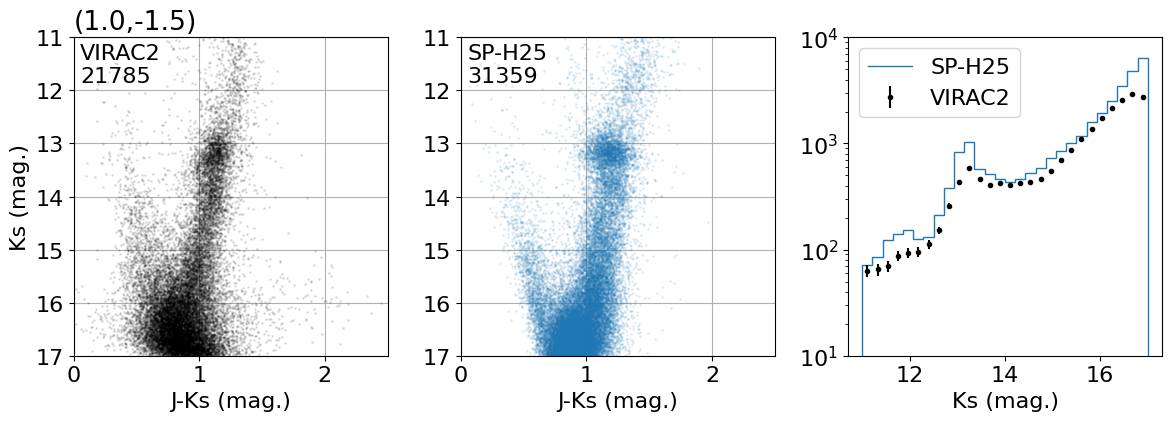

In [11]:
make_cmd_v2(1,-1.5,clim=[0,2.5])

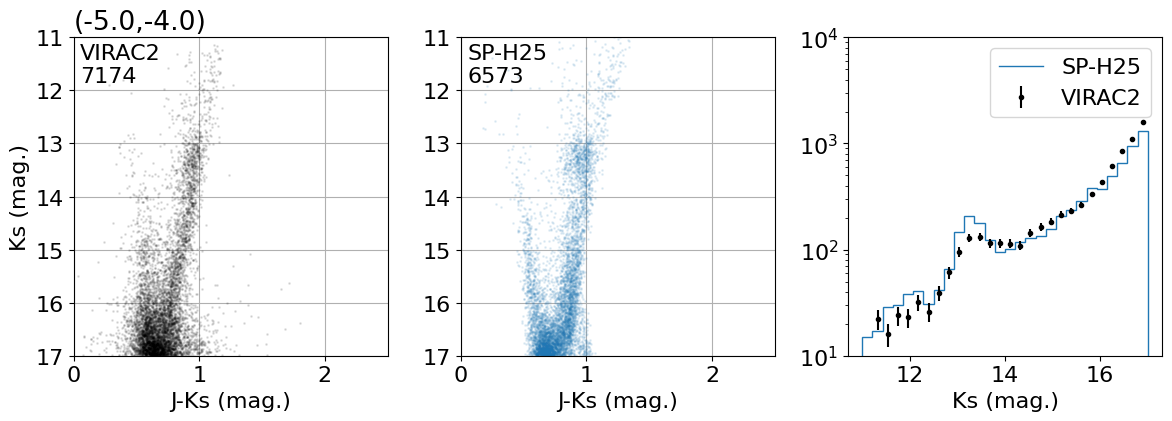

In [12]:
make_cmd_v2(-5,-4,clim=[0,2.5])

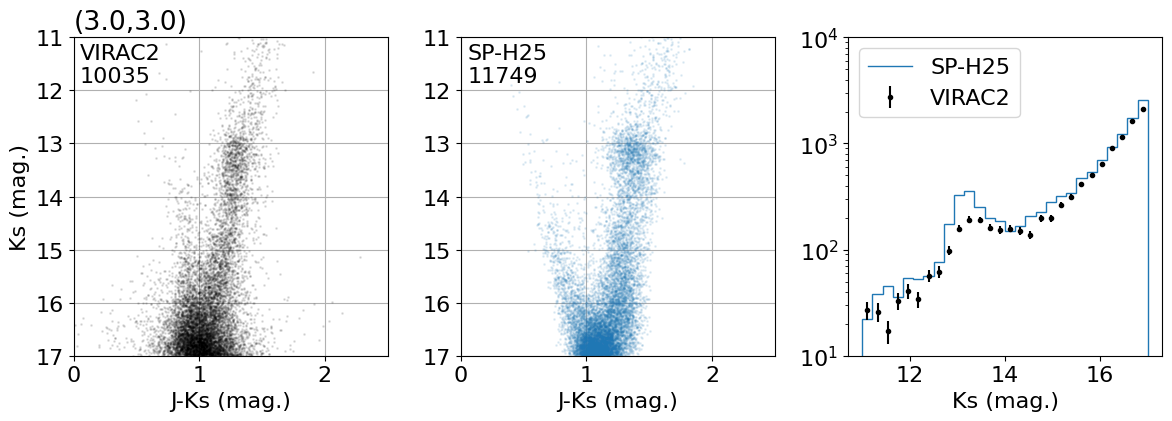

In [13]:
make_cmd_v2(3,3,clim=[0,2.5])

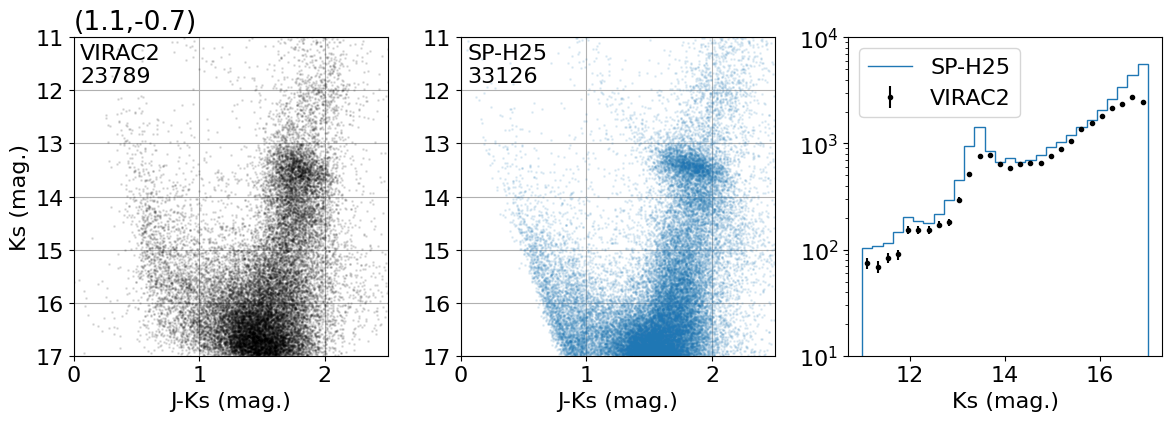

In [14]:
make_cmd_v2(1.1,-0.7,clim=[0,2.5])

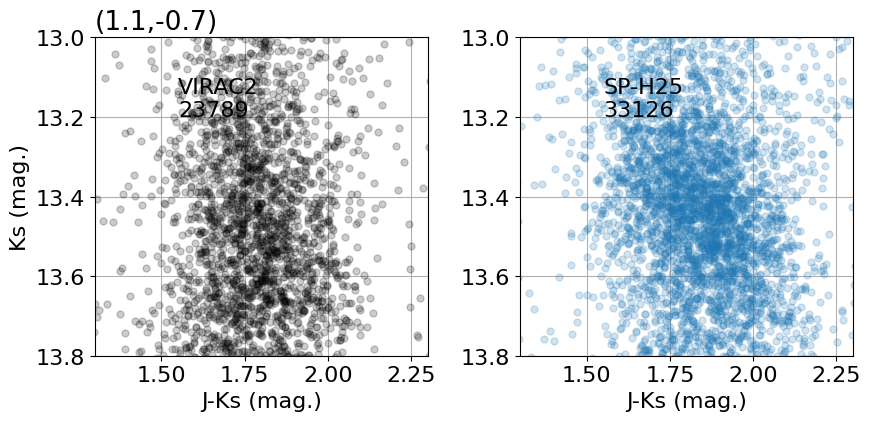

In [15]:
l,b = 1.1,-0.7; clim=[0,2.5]; Kslim=17
plt.rcParams["font.size"] = 16
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(9,4.5))
tab=get_virac2(l,b)
tab = tab[tab['Ksmag']<Kslim]
sptab=get_spcat(l,b)
sptab = sptab[sptab['VISTA_Ks']<Kslim]
ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=10, alpha=0.2, rasterized=True)
ax[1].plot(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], '.', markersize=10, alpha=0.2, rasterized=True)
ax[0].set_xlabel('J-Ks (mag.)')
ax[1].set_xlabel('J-Ks (mag.)')
ax[0].set_title(f'({l:.1f},{b:.1f})',loc='left')
#ax[1].set_title('SP-H25',loc='left')
for axi in ax:
    axi.set_ylim(13.8,13)
    axi.set_xlim(1.3,2.3)
ax[0].set_ylabel('Ks (mag.)')
ax[0].text(1.5+0.05,13.1, 'VIRAC2\n'+str(len(tab[(tab['Ksmag']<Kslim) & (tab['Ksmag']>11)])),
           ha='left',va='top')
ax[1].text(1.5+0.05,13.1, 'SP-H25\n'+str(len(sptab[(sptab['VISTA_Ks']<Kslim) & (sptab['VISTA_Ks']>11)])),
           ha='left',va='top')
ax[0].grid(True)
ax[1].grid(True)
plt.tight_layout()
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.png')    
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.pdf', dpi=600)

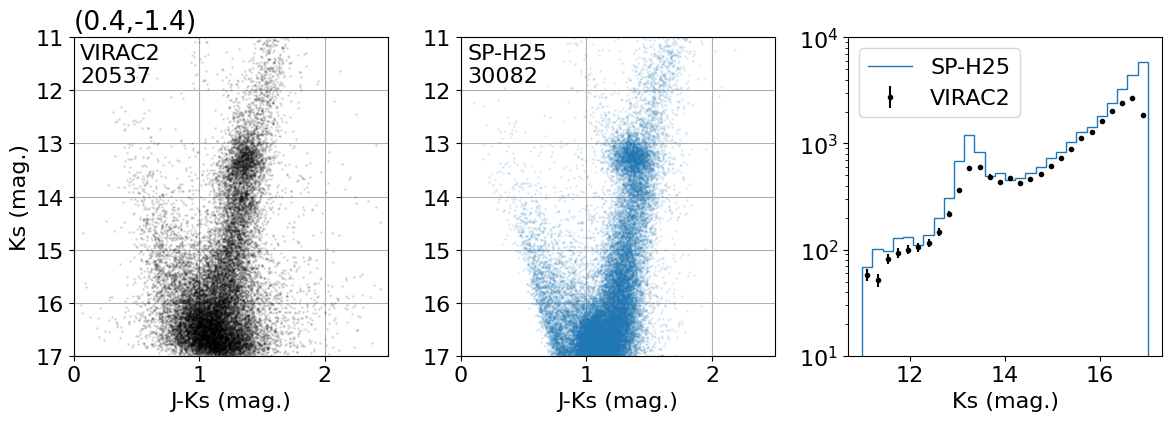

In [16]:
make_cmd_v2(0.4,-1.4,clim=[0,2.5])

-1.2321367 0.49925268
0.20940138 0.48338634
6.1080956 10.713116


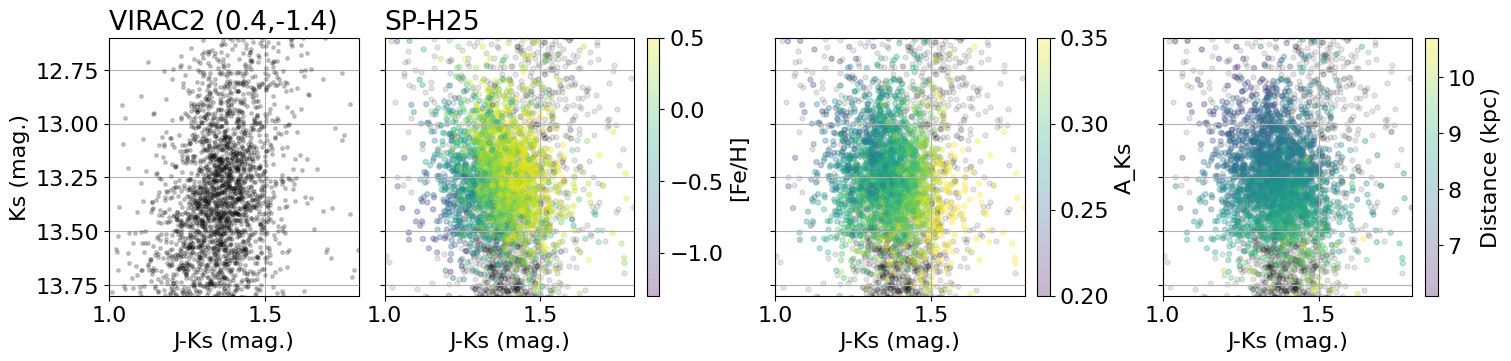

In [17]:
l,b = 0.4,-1.4; clim=[0,2.5]; Kslim=17
plt.rcParams["font.size"] = 16
fig,ax=plt.subplots(nrows=1,ncols=4,figsize=(15,3.5),sharey=True, layout='constrained')
tab=get_virac2(l,b)
tab = tab[tab['Ksmag']<Kslim]
sptab0=get_spcat(l,b,blend=False)
sptab = sptab0[(sptab0['VISTA_Ks']<Kslim) & (np.abs(sptab0['phase']-3)<0.5) & (sptab0['pop']==0.0)]
sptab2 = sptab0[(sptab0['VISTA_Ks']<Kslim) & ((np.abs(sptab0['phase']-3)>0.5) | (sptab0['pop']!=0.0))]
ax[0].plot(tab['Jmag']-tab['Ksmag'], tab['Ksmag'], 'k.', markersize=5, alpha=0.2, rasterized=True)
c1 = ax[1].scatter(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], marker='.', 
              s=50, alpha=0.3, rasterized=True, c=sptab['Fe/H_initial'],cmap='viridis',vmin=-1.3,vmax=0.5)
ax[1].scatter(sptab2['VISTA_J']-sptab2['VISTA_Ks'], sptab2['VISTA_Ks'], marker='.', 
              s=50, alpha=0.1, rasterized=True, c='k',zorder=-100)
ax[2].scatter(sptab2['VISTA_J']-sptab2['VISTA_Ks'], sptab2['VISTA_Ks'], marker='.', 
              s=50, alpha=0.1, rasterized=True, c='k',zorder=-100)
ax[3].scatter(sptab2['VISTA_J']-sptab2['VISTA_Ks'], sptab2['VISTA_Ks'], marker='.', 
              s=50, alpha=0.1, rasterized=True, c='k',zorder=-100)
c2 = ax[2].scatter(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], marker='.', 
              s=50, alpha=0.3, rasterized=True, c=sptab['A_Ks'],cmap='viridis',vmin=0.2,vmax=0.35)
c3 = ax[3].scatter(sptab['VISTA_J']-sptab['VISTA_Ks'], sptab['VISTA_Ks'], marker='.', 
              s=50, alpha=0.3, rasterized=True, c=sptab['Dist'],cmap='viridis',vmin=6.1,vmax=10.7)
plt.colorbar(c1, label='[Fe/H]')
plt.colorbar(c2, label='A_Ks')
plt.colorbar(c3, label='Distance (kpc)')
sel = sptab[(sptab['VISTA_Ks']<13.8) & (sptab['VISTA_Ks']>12.6) & 
            (sptab['VISTA_J']-sptab['VISTA_Ks']>1) & 
            (sptab['VISTA_J']-sptab['VISTA_Ks']<1.8)]
print(np.min(sel['Fe/H_initial']), np.max(sel['Fe/H_initial']))
print(np.min(sel['A_Ks']), np.max(sel['A_Ks']))
print(np.min(sel['Dist']), np.max(sel['Dist']))
ax[0].set_title(f'VIRAC2 ({l:.1f},{b:.1f})',loc='left')
ax[1].set_title('SP-H25',loc='left')
for axi in ax:
    axi.set_ylim(13.8,12.6)
    axi.set_xlim(1.0,1.8)
    axi.set_xlabel('J-Ks (mag.)')
    axi.grid(True)
ax[0].set_ylabel('Ks (mag.)')
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.png')    
plt.savefig(f'figures/virac2_cmd_l{l:0.3f}_b{b:0.3f}_rc.pdf', dpi=600)

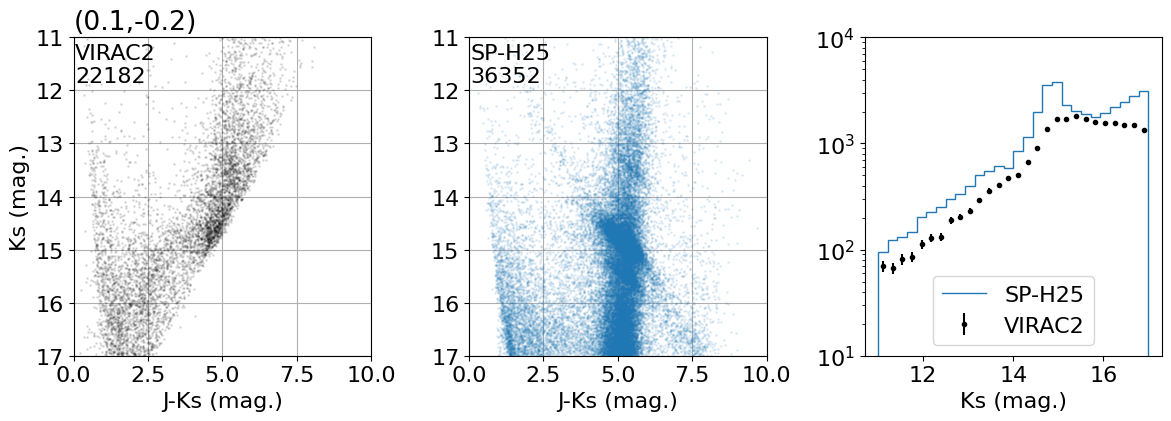

In [18]:
make_cmd_v2(0.05,-0.2,clim=[0,10])

In [19]:
def make_lf(l,b, clim=[0,1.5], ds=1,Kslim=18):
    fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(12,4))
    tab=get_virac2(l,b)[::ds]
    #tab = tab[tab['Ksmag']<Kslim]
    sptab=get_spcat(l,b)[::ds]
    #sptab = sptab[sptab['VISTA_Ks']<Kslim]

    magbins = np.linspace(11,Kslim,13)
    vlum = np.histogram(tab['Jmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_J'], bins=magbins)[0]
    ax[0].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum), label='VIRAC2',
                  linestyle='none', marker='.', c='k')
    ax[0].stairs(splum, magbins, label='SP-H25')
    ax[0].legend()
    ax[0].set_xlabel('J (mag.)')
    ax[0].set_title('Luminosity Function', loc='left')
    ax[0].set_yscale('log')

    magbins = np.linspace(11,Kslim,13)
    vlum = np.histogram(tab['Hmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_H'], bins=magbins)[0]
    ax[1].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum), label='VIRAC2',
                  linestyle='none', marker='.', c='k')
    ax[1].stairs(splum, magbins, label='SP-H25')
    ax[1].legend()
    ax[1].set_xlabel('H (mag.)')
    ax[1].set_title('Luminosity Function', loc='left')
    ax[1].set_yscale('log')

    magbins = np.linspace(11,Kslim,13)
    vlum = np.histogram(tab['Ksmag'], bins=magbins)[0]
    splum = np.histogram(sptab['VISTA_Ks'], bins=magbins)[0]
    ax[2].errorbar(magbins[:-1]+np.diff(magbins)/2, vlum, yerr=np.sqrt(vlum), label='VIRAC2',
                  linestyle='none', marker='.', c='k')
    ax[2].stairs(splum, magbins, label='SP-H25')
    ax[2].legend()
    ax[2].set_xlabel('Ks (mag.)')
    ax[2].set_title('Luminosity Function', loc='left')
    ax[2].set_yscale('log')

    plt.savefig(f'figures/virac2_lf_l{l:0.3f}_b{b:0.3f}.png')    
    plt.savefig(f'figures/virac2_lf_l{l:0.3f}_b{b:0.3f}.pdf', dpi=600)

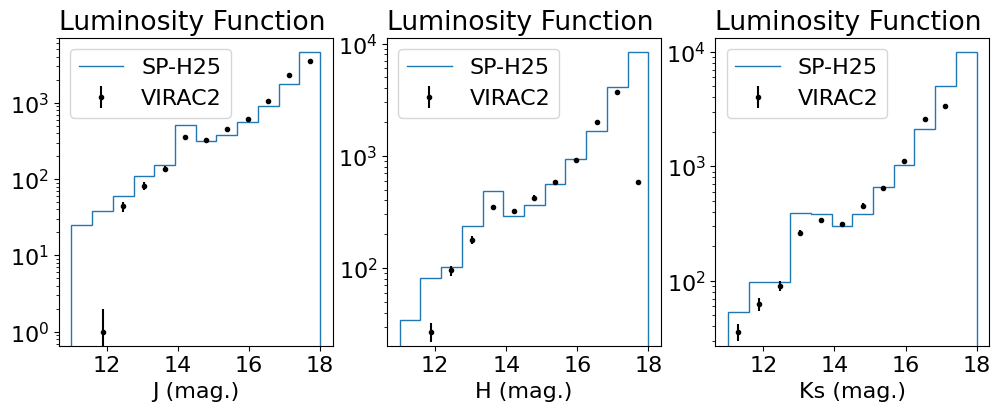

In [20]:
make_lf(-5,-4)

  0%|          | 0/103372 [00:00<?, ?it/s]

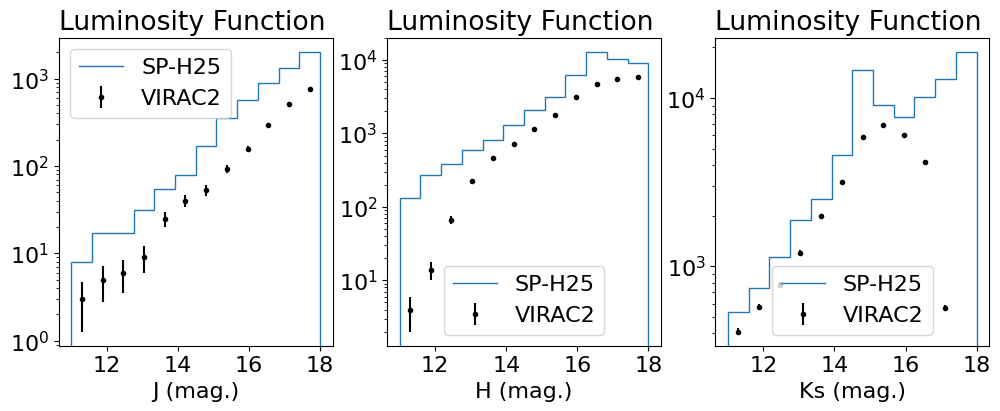

In [21]:
make_lf(0,0)

  0%|          | 0/41840 [00:00<?, ?it/s]

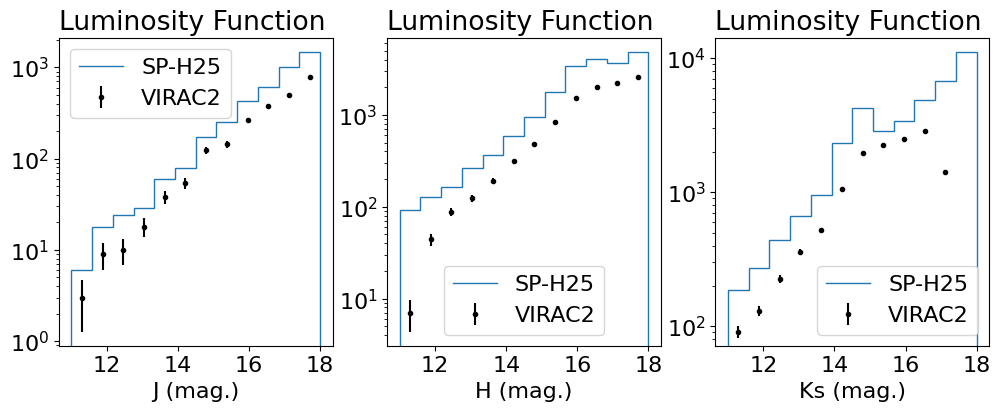

In [22]:
make_lf(0,-0.5)

In [92]:
# for l in range(-10,11):
#     for b in range(-10,6):
#         get_virac2(l,b)

Querying VIRAC2 10 5


In [ ]:
for l in range(-10,11):
    for b in range(-10,6):
        generate_spcat(l,b)



############################# update location #############################
 2664610 - # set location to: 
 2664611 - l, b = (-10.00 deg, -10.00 deg)
 2664612 - # set solid_angle to:
 2664613 - solid_angle = 7.854e-03 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
 2671705 - bulge : estimate minimum mass for magnitude limit
 2671741 - # From density profile (number density)
 2671741 - expected_total_iMass = 19156.8030
 2671742 - expected_total_eMass = 10509.2866
 2671742 - average_iMass_per_star = 0.5739
 2671742 - mass_loss_correction = 0.5486
 2671742 - n_expected_stars = 33382.0169
 2671743 - without_lm_stars = 33382.0152
 2671743 - # Determine velocities when position are generated 
 2672077 - # From Generated Field:
 2672077 - generated_stars = 26205
 2672077 - generated_total_iMass = 8403.2246
 2672084 - generated_total_iMass_incl_lowmass = 8403.2246
 2672084 - gen

  0%|          | 0/267768 [00:00<?, ?it/s]

 2739353 - # From Generated Field:
 2739353 - generated_stars = 210325
 2739353 - generated_total_iMass = 67717.7199
 2739373 - generated_total_iMass_incl_lowmass = 67717.7199
 2739373 - generated_total_eMass = 67705.6557
 2739377 - generated_total_eMass_incl_lowmass = 67705.6557
 2739377 - det_mass_loss_corr = 0.9998
 2739378 - det_mass_loss_corr_incl_lowmass = 0.9998218459343656
 2739381 - # Done


# Population 1;  halo -----------------------------------------------------
 2739733 - halo : estimate minimum mass for magnitude limit
 2739769 - # From density profile (number density)
 2739769 - expected_total_iMass = 687.3833
 2739769 - expected_total_eMass = 362.1638
 2739769 - average_iMass_per_star = 0.5739
 2739770 - mass_loss_correction = 0.5269
 2739770 - n_expected_stars = 1197.8116
 2739770 - without_lm_stars = 1188.0747
 2739770 - # Determine velocities when position are generated 
 2739816 - # From Generated Field:
 2739817 - generated_stars = 875
 2739817 - generated_total_i

  0%|          | 0/274367 [00:00<?, ?it/s]

 2754489 - # From Generated Field:
 2754490 - generated_stars = 213700
 2754490 - generated_total_iMass = 69235.3363
 2754508 - generated_total_iMass_incl_lowmass = 69235.3363
 2754509 - generated_total_eMass = 69221.6221
 2754512 - generated_total_eMass_incl_lowmass = 69221.6221
 2754513 - det_mass_loss_corr = 0.9998
 2754513 - det_mass_loss_corr_incl_lowmass = 0.9998019194918962
 2754516 - # Done


# Population 1;  halo -----------------------------------------------------
 2754855 - halo : estimate minimum mass for magnitude limit
 2754890 - # From density profile (number density)
 2754890 - expected_total_iMass = 725.6985
 2754891 - expected_total_eMass = 382.3511
 2754891 - average_iMass_per_star = 0.5739
 2754891 - mass_loss_correction = 0.5269
 2754891 - n_expected_stars = 1264.5784
 2754892 - without_lm_stars = 1254.7920
 2754892 - # Determine velocities when position are generated 
 2754941 - # From Generated Field:
 2754941 - generated_stars = 926
 2754941 - generated_total_i

...

 6638385 - # From Generated Field:
 6638385 - generated_stars = 4075439
 6638386 - generated_total_iMass = 1310631.4501
 6638678 - generated_total_iMass_incl_lowmass = 1310631.4501
 6638678 - generated_total_eMass = 1310390.3265
 6638746 - generated_total_eMass_incl_lowmass = 1310390.3265
 6638747 - det_mass_loss_corr = 0.9998
 6638747 - det_mass_loss_corr_incl_lowmass = 0.9998160248821502
 6638787 - # Done


# Population 1;  halo -----------------------------------------------------
 6639154 - halo : estimate minimum mass for magnitude limit
 6639189 - # From density profile (number density)
 6639189 - expected_total_iMass = 4004.0711
 6639189 - expected_total_eMass = 2109.6376
 6639189 - average_iMass_per_star = 0.5739
 6639190 - mass_loss_correction = 0.5269
 6639190 - n_expected_stars = 6977.3631
 6639190 - without_lm_stars = 6967.2243
 6639190 - # Determine velocities when position are generated 
 6639296 - # From Generated Field:
 6639296 - generated_stars = 5190
 6639296 - gener

  0%|          | 0/483596 [00:00<?, ?it/s]

 6679924 - # From Generated Field:
 6679924 - generated_stars = 341262
 6679925 - generated_total_iMass = 116140.0554
 6679953 - generated_total_iMass_incl_lowmass = 116380.7080
 6679953 - generated_total_eMass = 116119.8456
 6679959 - generated_total_eMass_incl_lowmass = 116360.4982
 6679959 - det_mass_loss_corr = 0.9998
 6679960 - det_mass_loss_corr_incl_lowmass = 0.9998263471577933
 6679964 - # Done


########################### Combine Populations ###########################
 6680071 - Number of stars generated: 4880237 (25 columns)
 6680072 - remove stars which are outside of the isochrone grid 
 6680714 - cleand field: Number of stars generated: 4880237 (25 columns)
 6680715 - included_columns = ['pop', 'iMass', 'age', 'Fe/H_initial', 'Mass', 'In_Final_Phase', 'Dist', 'l', 'b', 'vr_bc', 'mul', 'mub', 'x', 'y', 'z', 'U', 'V', 'W', 'VR_LSR', 'A_Ks', 'VISTA_Z', 'VISTA_Y', 'VISTA_J', 'VISTA_H', 'VISTA_Ks']


# Save result -------------------------------------------------------------


  0%|          | 0/3932350 [00:00<?, ?it/s]

 6725549 - # From Generated Field:
 6725550 - generated_stars = 3104916
 6725550 - generated_total_iMass = 995224.5283
 6725783 - generated_total_iMass_incl_lowmass = 995224.5283
 6725784 - generated_total_eMass = 995028.4302
 6725830 - generated_total_eMass_incl_lowmass = 995028.4302
 6725831 - det_mass_loss_corr = 0.9998
 6725831 - det_mass_loss_corr_incl_lowmass = 0.9998029609112536
 6725861 - # Done


# Population 1;  halo -----------------------------------------------------
 6726193 - halo : estimate minimum mass for magnitude limit
 6726228 - # From density profile (number density)
 6726229 - expected_total_iMass = 3455.1532
 6726229 - expected_total_eMass = 1820.4275
 6726229 - average_iMass_per_star = 0.5739
 6726230 - mass_loss_correction = 0.5269
 6726230 - n_expected_stars = 6020.8368
 6726230 - without_lm_stars = 6010.7114
 6726231 - # Determine velocities when position are generated 
 6726315 - # From Generated Field:
 6726316 - generated_stars = 4567
 6726316 - generated

In [ ]:
for l in range(-10,11):
    for b in range(-10,6):
        print(l,b)
        get_spcat(l,b)

In [25]:
ls,bs,vmul,smul,vmub,smub = [],[],[],[],[],[]
for l in range(-10,11):
    for b in range(-10,6):
        vcat = get_virac2(l,b)
        vcat = vcat[vcat['MedKsmag']<16]
        scat = get_spcat(l,b,blend=False)
        scat = scat[scat['VISTA_Ks']<16]
        ls.append(l); bs.append(b)
        vmul.append(np.median(vcat['pml']))
        vmub.append(np.median(vcat['pmb']))
        smul.append(np.median(scat['mul']))
        smub.append(np.median(scat['mub']))

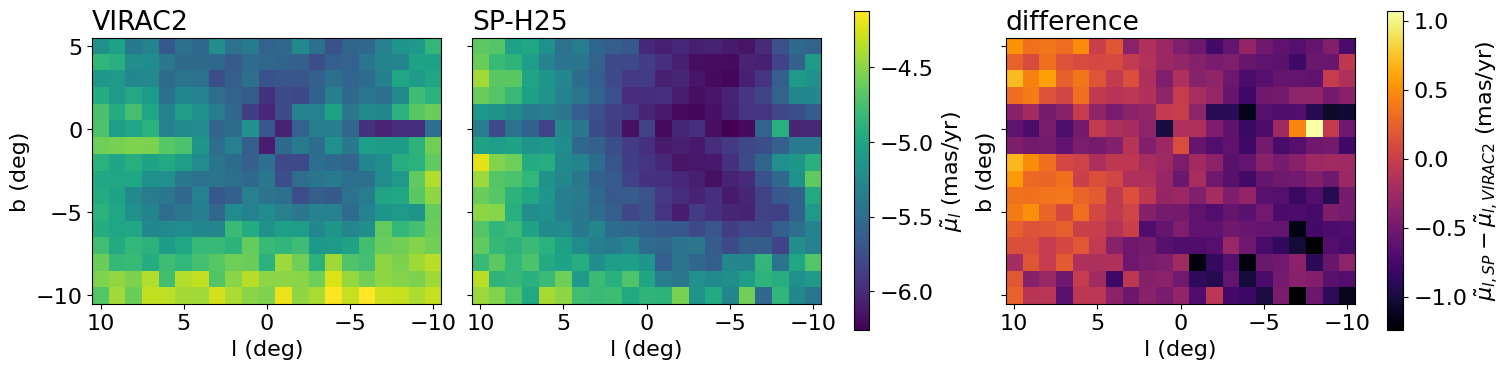

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharey=True)

vmin = np.min(vmul+smul)
vmax = np.max(vmul+smul)

vmuls = np.reshape(vmul,(21,16)).T
virac = axes[0].imshow(vmuls, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("VIRAC2", loc='left')
axes[0].set_xlabel("l (deg)")
axes[0].set_ylabel("b (deg)")
axes[0].invert_xaxis()

smuls = np.reshape(smul,(21,16)).T
synthpop = axes[1].imshow(smuls, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("SP-H25", loc='left')
axes[1].set_xlabel("l (deg)")
axes[1].invert_xaxis()
fig.colorbar(synthpop, ax=axes[1], orientation="vertical", label=r"$\tilde{\mu}_l$ (mas/yr)", shrink=0.65)


diff = axes[2].imshow(smuls-vmuls, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="inferno")#, vmin=vmin, vmax=vmax)
axes[2].set_title("difference", loc='left')
axes[2].set_xlabel("l (deg)")
axes[2].set_ylabel("b (deg)")
axes[2].invert_xaxis()

fig.colorbar(diff, ax=axes[2], orientation="vertical", 
             label=r"$\tilde{\mu}_{l,SP}-\tilde{\mu}_{l,VIRAC2}$ (mas/yr)", shrink=0.65)

plt.savefig("figures/virac_mul_maps.pdf")
plt.show()

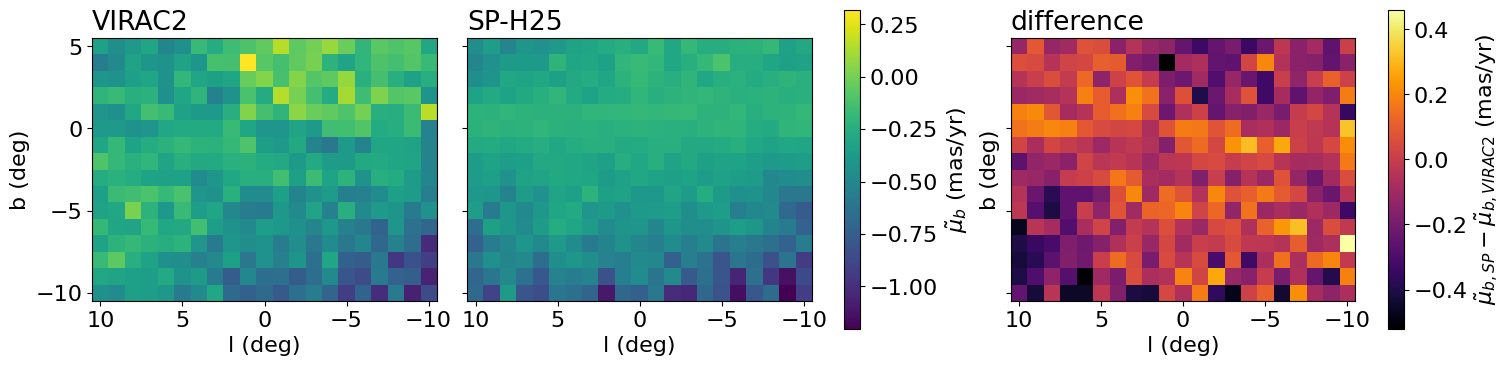

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharey=True)

vmin = np.min(vmub+smub)
vmax = np.max(vmub+smub)

vmubs = np.reshape(vmub,(21,16)).T
virac = axes[0].imshow(vmubs, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("VIRAC2", loc='left')
axes[0].set_xlabel("l (deg)")
axes[0].set_ylabel("b (deg)")
axes[0].invert_xaxis()

smubs = np.reshape(smub,(21,16)).T
synthpop = axes[1].imshow(smubs, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("SP-H25", loc='left')
axes[1].set_xlabel("l (deg)")
axes[1].invert_xaxis()
fig.colorbar(synthpop, ax=axes[1], orientation="vertical", label=r"$\tilde{\mu}_b$ (mas/yr)", shrink=0.65)


diff = axes[2].imshow(smubs-vmubs, origin="lower",
                     extent=[-10.5,10.5,-10.5,5.5],
                     aspect="equal", cmap="inferno")#, vmin=vmin, vmax=vmax)
axes[2].set_title("difference", loc='left')
axes[2].set_xlabel("l (deg)")
axes[2].set_ylabel("b (deg)")
axes[2].invert_xaxis()

fig.colorbar(diff, ax=axes[2], orientation="vertical", 
             label=r"$\tilde{\mu}_{b,SP}-\tilde{\mu}_{b,VIRAC2}$ (mas/yr)", shrink=0.65)

plt.savefig("figures/virac_mub_maps.pdf")
plt.show()

In [ ]:
def plot_hist(l,b,maglim=16):
    vcat = get_virac2(l,b)
    vcat = vcat[vcat['MedKsmag']<maglim]
    scat = get_spcat(l,b)
    scat = scat[scat['VISTA_Ks']<maglim]

    mulbins = np.linspace(-25,15,21)
    vhist,_ = np.histogram(vcat['pml'], bins=mulbins)
    plt.errorbar(mulbins[1:]-np.diff(mulbins)/2, vhist/np.sum(vhist), yerr=np.sqrt(vhist)/np.sum(vhist), 
                 marker='.', color='k', linestyle='none')
    shist,_ = np.histogram(scat['mul'], bins=mulbins)
    plt.stairs(shist/np.sum(shist), mulbins)